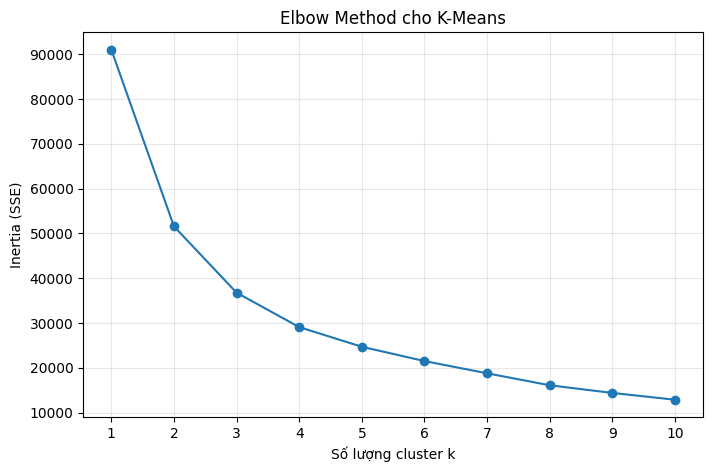

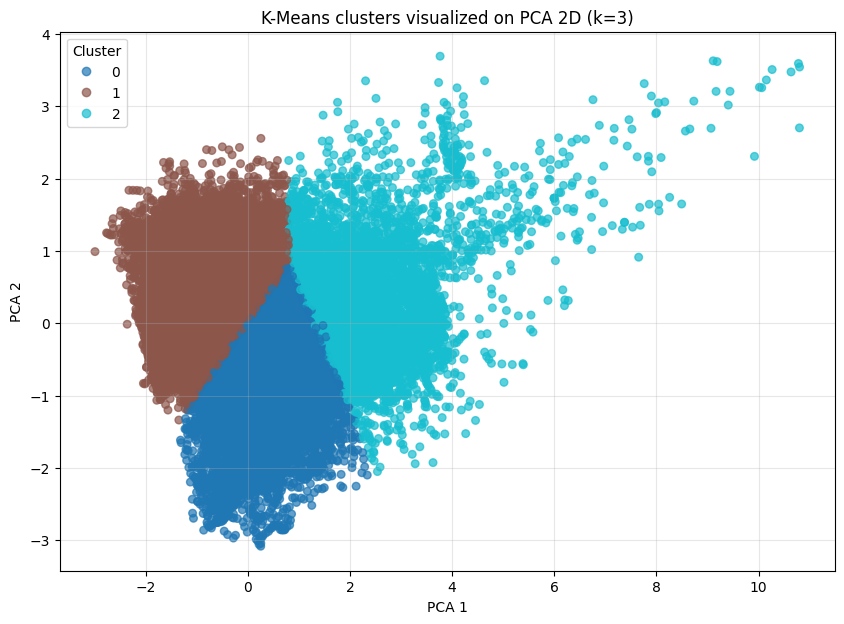

Cluster centroids (original scale):
            aqi    pm25  temperature
cluster                             
0        125.69   46.46        19.55
1         95.28   32.14        28.79
2        220.11  123.92        21.35

Cluster size:
cluster
0     9001
1    16621
2     4719
Name: count, dtype: int64

Mean AQI by cluster:
cluster
0    125.70
1     95.37
2    220.20
Name: aqi, dtype: float64

Cluster distribution by season:
season_name     0     1     2     3
cluster                            
0            5093  2762    31  1115
1             396  4735  7186  4304
2            2120  1338   127  1134

Cluster distribution by hour:
hour         0
cluster       
0         9001
1        16621
2         4719

Hour with most members in each cluster:
cluster
0    0
1    0
2    0
dtype: int32

Clusters ranked by mean AQI:
cluster
2    220.20
0    125.70
1     95.37
Name: aqi, dtype: float64


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load dữ liệu đã làm sạch
try:
    df = pd.read_csv('../clean/hanoi_aqi_cleaned.csv', low_memory=False, on_bad_lines='skip')
except Exception as e:
    print(f"Error reading cleaned file: {e}")
    # Fallback: load and combine raw data
    files = ['../data_raw/2022.csv', '../data_raw/2023.csv', '../data_raw/2024.csv', '../data_raw/2025.csv']
    df_list = []
    for f in files:
        try:
            df_list.append(pd.read_csv(f, low_memory=False, on_bad_lines='skip'))
        except:
            pass
    df = pd.concat(df_list, ignore_index=True)

df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Chọn các đặc trưng số để clustering
feature_cols = [c for c in ['aqi', 'pm25', 'temperature', 'humidity'] if c in df.columns]
X = df[feature_cols].dropna()

# Chuẩn hóa trước khi clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method tìm k tối ưu
inertia = []
ks = list(range(1, 11))
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(ks, inertia, marker='o')
plt.xticks(ks)
plt.xlabel('Số lượng cluster k')
plt.ylabel('Inertia (SSE)')
plt.title('Elbow Method cho K-Means')
plt.grid(alpha=0.3)
plt.show()

# Chọn k từ elbow plot (điền giá trị phù hợp sau khi quan sát)
k_opt = 3
km = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled)

# Visualize cluster trên PCA 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=30, alpha=0.7)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title(f'K-Means clusters visualized on PCA 2D (k={k_opt})')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.grid(alpha=0.3)
plt.show()

# Phân tích đặc trưng từng cluster
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(km.cluster_centers_),
    columns=X.columns
)
cluster_centers.index.name = 'cluster'
print('Cluster centroids (original scale):')
print(cluster_centers.round(2))

# Gắn nhãn cluster vào DataFrame gốc để phân tích mùa / giờ
clustered_df = df.loc[X.index].copy()
clustered_df['cluster'] = labels
if 'date' in clustered_df.columns:
    clustered_df['hour'] = clustered_df['date'].dt.hour
    clustered_df['month'] = clustered_df['date'].dt.month

if 'season' in clustered_df.columns:
    clustered_df['season_name'] = clustered_df['season']
elif 'month' in clustered_df.columns:
    clustered_df['season_name'] = pd.cut(
        clustered_df['month'],
        bins=[0, 3, 6, 9, 12],
        labels=['Winter', 'Spring', 'Summer', 'Autumn'],
        right=True
    )

print('\nCluster size:')
print(clustered_df['cluster'].value_counts().sort_index())

if 'aqi' in clustered_df.columns:
    print('\nMean AQI by cluster:')
    print(clustered_df.groupby('cluster')['aqi'].mean().round(2))

if 'season_name' in clustered_df.columns:
    print('\nCluster distribution by season:')
    print(clustered_df.groupby(['cluster', 'season_name']).size().unstack(fill_value=0))

if 'hour' in clustered_df.columns:
    print('\nCluster distribution by hour:')
    hour_counts = clustered_df.groupby(['cluster', 'hour']).size().unstack(fill_value=0)
    print(hour_counts)
    top_hours = hour_counts.idxmax(axis=1)
    print('\nHour with most members in each cluster:')
    print(top_hours)

if 'aqi' in clustered_df.columns:
    aqi_cluster = clustered_df.groupby('cluster')['aqi'].mean().sort_values(ascending=False)
    print('\nClusters ranked by mean AQI:')
    print(aqi_cluster.round(2))


In [ ]:
import pandas as pd

# Show full table output instead of truncated notebook display
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

if 'season_name' in clustered_df.columns:
    print('\nCluster distribution by season:')
    season_table = clustered_df.groupby(['cluster', 'season_name']).size().unstack(fill_value=0)
    print(season_table.to_string())

if 'hour' in clustered_df.columns:
    print('\nCluster distribution by hour:')
    hour_counts = clustered_df.groupby(['cluster', 'hour']).size().unstack(fill_value=0)
    print(hour_counts.to_string())
    top_hours = hour_counts.idxmax(axis=1)
    print('\nHour with most members in each cluster:')
    print(top_hours.to_string())

if 'aqi' in clustered_df.columns:
    print('\nClusters ranked by mean AQI:')
    print(aqi_cluster.round(2).to_string())
